# Exercise 1: Supervised Classification (EEG → Sleep Staging)

## Context: Sleep Staging and its Clinical Importance

**What is Sleep Staging?**

Sleep staging is the process of classifying sleep into distinct physiological states based on neurophysiological recordings, primarily electroencephalography (EEG). This classification is fundamental to understanding sleep architecture and diagnosing sleep disorders.

**The Five Sleep Stages:**

1. **Wake (W)**: Active consciousness with eyes open or closed, characterized by high-frequency, low-amplitude EEG activity (alpha and beta rhythms when relaxed).

2. **N1 (NREM Stage 1)**: Light sleep transition from wakefulness. EEG shows theta activity (4-8 Hz) and disappearance of alpha rhythms. Easily disrupted by external stimuli.

3. **N2 (NREM Stage 2)**: Consolidated light sleep accounting for ~50% of total sleep time. Distinguished by sleep spindles (11-16 Hz bursts in the sigma band) and K-complexes (sharp negative deflections followed by positive components).

4. **N3 (NREM Stage 3 / Slow-Wave Sleep)**: Deep restorative sleep dominated by high-amplitude delta waves (<4 Hz). Critical for physical restoration, immune function, and memory consolidation. Difficult to awaken from.

5. **REM (Rapid Eye Movement)**: Paradoxical sleep with high-frequency, low-amplitude EEG resembling wakefulness, but with muscle atonia and rapid eye movements. Primary stage for vivid dreaming and emotional memory processing.


The goal is to classify sleep stages (Wake, N1, N2, N3, REM) from EEG spectral features (Power Spectral Density - PSD). The sampling unit is an **epoch** (typically 30 seconds), and for each epoch we have a feature vector of powers at discrete frequencies. The challenge lies in capturing subtle spectral signatures that distinguish stages while generalizing across subjects with different age, sex, and neurophysiology.

---

## Learning Objectives

- Load and inspect EEG spectral features for multiple subjects
- Visualize stage-wise mean PSD and understand canonical EEG bands (δ, θ, α, σ, β)
- Define a preprocessing pipeline (log/dB scaling + standardization)
- Compare supervised classifiers with cross-subject validation (no leakage)
- Engineer band-level features and contrast them with PCA-based dimensionality reduction
- Train the best model on the full training set, persist it, and evaluate on unseen subjects



## Setup and libraries
We import core libraries (NumPy, Matplotlib, PyTorch for loading features saved as tensors, and tqdm for progress bars).

In [2]:
%matplotlib inline
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import torch
from tqdm import tqdm

# preprocessing pipeline
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

from sklearn.base import clone
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as tree
from sklearn.svm import SVC

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)

from pickle import dump, load


## Data and features
This section defines:
- The mapping of sleep stages and their colors for visualization;
- EEG frequency bands (delta, theta, alpha, sigma, beta);
- Utility functions to read per-subject features (epoch-wise PSD) and convert to dB;
- A plotting routine that shows, for each subject, the stage-wise mean PSD.

Practical notes:
- PSD are in µV²/Hz; the logarithmic (dB) scale improves interpretability across stages;
- Ensure the available `freqs` cover the band limits before drawing vertical lines;
- Inspect within-subject variability: strong differences motivate standardization.

Guiding questions:
- Which bands are most discriminative (e.g., sigma enhancements in N2/N3)?
- Do the power distributions show outliers suggesting robust scaling?
- Are class labels balanced across stages? If not, metrics like balanced accuracy are preferable.

In [3]:
# utility contants

# id corresponding to each sleep stage
ID_STAGES = {
    0: "W",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "R",
}

# list of sleep stages and their corresponding colors for plotting
STAGES = ["Wake", "N1", "N2", "N3", "REM"]
STAGE_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## Exercise 1.1: Utility Functions for Data Loading and Visualization

In this section, we define three essential utility functions that form the foundation of our analysis:

1. **`read_subject_features()`**: Loads pre-computed PSD features, frequency bins, and sleep stage labels from disk for a given subject.

2. **`power_scale()`**: Converts PSD values from linear scale (µV²/Hz) to logarithmic scale (dB). This transformation is critical for:
   - **Visualization**: Makes the wide dynamic range of power values more interpretable
   - **Numerical stability**: Reduces the impact of extreme outliers on downstream processing
   - **Feature engineering**: Many classifiers benefit from more normally-distributed features

3. **`plot_and_fetch_subjects_features()`**: Creates a comprehensive visualization showing the mean PSD spectrum for each sleep stage across multiple subjects. This function:
   - Plots stage-wise spectral profiles with EEG frequency band markers
   - Enables quick visual assessment of inter-subject variability
   - Returns the loaded data in a format ready for machine learning pipelines

**Implementation Notes:**

- All PSD data are in **µV²/Hz** (microvolts squared per Hz), the standard unit for EEG power spectral density
- The frequency bands (delta, theta, alpha, sigma, beta) are marked with vertical lines to aid interpretation
- Colors are consistent across all visualizations for easy stage identification

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
base = "/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/"

print(os.listdir(base))

['BDP Exercise session 1 ', 'BDP ES2: Data driven filtering', 'EX3: Correlation and spectral analysis + template matching', 'Filtering_practice.ipynb', 'Time_freq_analysis_lecture.ipynb', '4 Peak detection and spectral analysis', 'new ']


In [6]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/new /EX6: Advanced classification"

# folder inside the exercise directory
features_folder = os.path.join(base_path, "data", "features")
stages_folder = os.path.join(base_path, "data", "stages")

def read_subject_features(i: int) -> Tuple[np.array, np.array, np.array]:
    """
    Read features, frequencies, and stages for a given subject.

    Loads pre-computed power spectral density (PSD) features, frequency bins,
    and sleep stage labels from PyTorch tensor files for a specific subject.

    Parameters
    ----------
    i : int
        Subject index (0-based indexing).

    Returns
    -------
    features : np.array
        2D array of shape (n_samples, n_features) containing PSD values in µV²/Hz,
        where n_samples is the number of epochs and n_features is the number of
        frequency bins.
    stages : np.array
        1D array of shape (n_samples,) containing sleep stage labels (0=Wake,
        1=N1, 2=N2, 3=N3, 4=REM).
    freqs : np.array
        1D array of shape (n_features,) containing frequency values in Hz
        corresponding to each feature column.

    Examples
    --------
    >>> features, stages, freqs = read_subject_features(0)
    >>> print(f"Subject 0: {features.shape[0]} epochs, {features.shape[1]} frequencies")
    >>> print(f"Frequency range: {freqs.min():.1f} - {freqs.max():.1f} Hz")
    """

    # features = torch.load(f"data/features/subject_{i}.pt").float().numpy()
    # freqs = torch.load(f"data/features/freqs_{i}.pt").float().numpy()
    # stages = torch.load(f"data/stages/subject_{i}.pt").long().numpy() - 1
    features = torch.load(os.path.join(features_folder, f"subject_{i}.pt")).float().numpy()
    freqs    = torch.load(os.path.join(features_folder, f"freqs_{i}.pt")).float().numpy()
    stages   = torch.load(os.path.join(stages_folder,  f"subject_{i}.pt")).long().numpy() - 1

    return features, stages, freqs


def power_scale(x: np.array) -> np.array:
    """
    Convert power spectral density from linear to logarithmic (dB) scale.

    Transforms PSD values in µV²/Hz to decibel scale for improved visualization
    and numerical stability. The transformation applies floor threshold to avoid
    log of zero or negative values.

    Parameters
    ----------
    x : np.array
        Input array containing power spectral density values in µV²/Hz.
        Can be 1D or 2D (n_samples, n_features).

    Returns
    -------
    psd_db : np.array
        Power spectral density in dB scale (10 * log10(PSD)).
        Same shape as input array.

    Examples
    --------
    >>> psd_linear = np.array([1e-6, 1e-5, 1e-4])  # in µV²/Hz
    >>> psd_db = power_scale(psd_linear)
    >>> print(psd_db)  # Values in dB scale
    """
    eps = 1e-10
    x = np.maximum(x, eps)
    psd_db = 10 * np.log10(x)
    return psd_db


def plot_and_fetch_subjects_features(
    n_subjects: int = 10,
    ncol: int = 5,
    nrows: int = 2,
    figsize: Tuple[int, int] = (15, 6),
    show_plot: bool = True,
) -> Tuple[List[np.array], List[np.array], np.array]:
    """
    Load multiple subjects' data and visualize stage-wise mean PSD spectra.

    Creates a grid of subplots showing the average power spectral density for each
    sleep stage across multiple subjects. Includes frequency band markers for the
    canonical EEG bands (delta, theta, alpha, sigma, beta).

    Parameters
    ----------
    n_subjects : int, optional
        Number of subjects to load and plot. Default is 10.
    ncol : int, optional
        Number of columns in the subplot grid. Default is 5.
    nrows : int, optional
        Number of rows in the subplot grid. Default is 2.
    figsize : Tuple[int, int], optional
        Figure size as (width, height) in inches. Default is (15, 6).

    Returns
    -------
    X : List[np.array]
        List of feature arrays, one per subject. Each array has shape
        (n_epochs, n_frequencies).
    y : List[np.array]
        List of stage label arrays, one per subject. Each array has shape (n_epochs,).
    freqs : np.array
        1D array of frequency bins in Hz (same for all subjects).

    Examples
    --------
    >>> features, stages, freqs = plot_and_fetch_subjects_features(n_subjects=5, ncol=5, nrows=1)
    >>> print(f"Loaded {len(features)} subjects")
    >>> print(f"Total epochs: {sum(len(s) for s in stages)}")
    """

    # create fig and axes with plt.subplots
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncol,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten()

    # loop over subjects

    X, y = [], []

    for idx, i in enumerate(tqdm(range(n_subjects), desc="Reading data")):
        ax = axes[idx]

        # read subject features
        features, stages, freqs = read_subject_features(i)

        # save the data by appending to a list
        X.append(features)
        y.append(stages)

        # unique stages present in this subject
        stage_ids = np.unique(stages)

        # now let's plot the mean PSD per stage for each subject
        for stage_id in stage_ids:
            mean_psd = features[stages == stage_id].mean(axis=0)
            ax.plot(freqs, mean_psd, label=ID_STAGES[stage_id], color=STAGE_COLORS[stage_id], linewidth=1.2)

        # Optional: draw vertical lines for each band
        for band_name, band_limits in BANDS.items():
            ax.axvspan(*band_limits, color="gray", alpha=0.2)

        ax.set_title(f"Subject {i+1}")
        ax.set_xlabel("Frequency (Hz)")
        # ax.set_ylabel("Power (dB)")
        if idx % ncol == 0:
            ax.set_ylabel("PSD (µV²/Hz)")

    # Global legend outside plot area
    if show_plot:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.12, 1))
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)


    return X, y, freqs


## Initial exploration and cross-subject comparison
We produce two visualizations:
1) a quick preview on 2 subjects for fast debugging;
2) an overview on 10 subjects to capture stage- and band-specific patterns.

What to look for:
- Inter-subject differences (absolute scale and spectral shape);
- Bands that are more stable or more variable;
- Potential artifacts or anomalous spectral peaks.

Reading data: 100%|██████████| 2/2 [00:08<00:00,  4.14s/it]


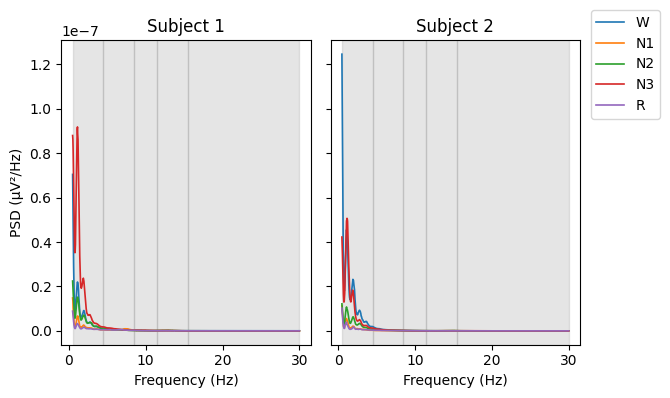

In [7]:
n_subjects = 2
nrows, ncol = 1, 2
figsize = (6, 4)

_, _, _ = plot_and_fetch_subjects_features(
    n_subjects=n_subjects, ncol=ncol, nrows=nrows, figsize=figsize
)

Reading data: 100%|██████████| 10/10 [00:23<00:00,  2.33s/it]


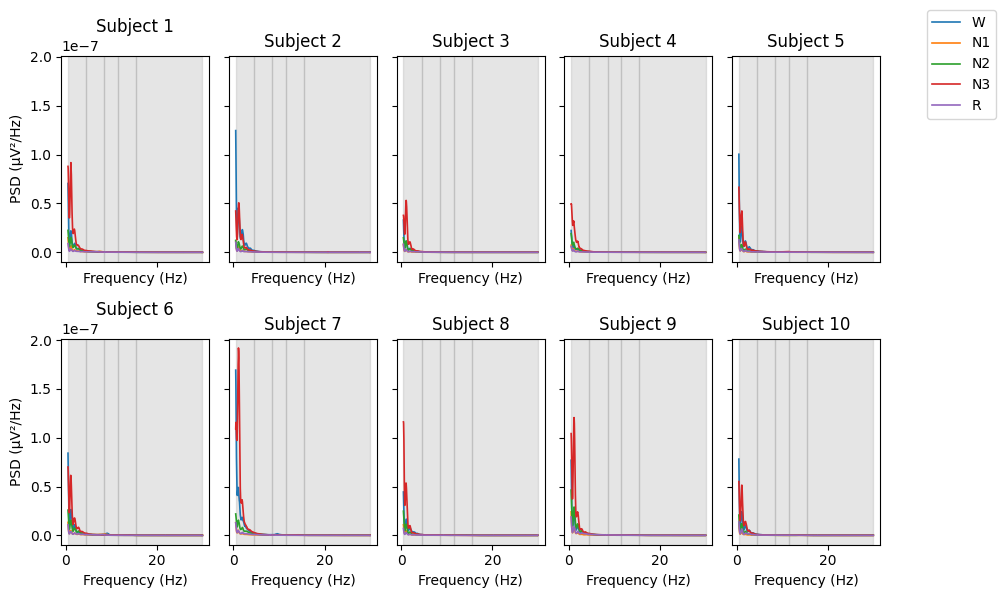

In [8]:
# Fetch the data of the first 10 subjects and plot their mean PSD per stage
n_subjects = 10
nrows, ncol = n_subjects // 5, 5
figsize = (9, 6)

features, stages, freqs = plot_and_fetch_subjects_features(
    n_subjects=n_subjects, ncol=ncol, nrows=nrows, figsize=figsize
)

## Exercise 1.2: Preprocessing Pipeline Construction

In this section, we build a preprocessing pipeline that transforms raw PSD features into a format suitable for machine learning.

### Why Preprocessing Matters

Machine learning algorithms make implicit assumptions about data distribution and scale:
- **SVM and kNN** are sensitive to feature magnitudes (features with larger ranges dominate distance calculations)
- **Logistic Regression** converges faster with standardized features
- **Tree-based methods** (Random Forest, Decision Trees) are scale-invariant but can still benefit from log-transforms

### The Preprocessing Pipeline

`power_scale` -> `standard_scaling`

Note:
- use  `make_pipeline` to build an sklearn-compliant machine learning pipeline
- combine `FunctionTransformer` with `power_scale` to create your custom pipeline step
- use `StandardScaler` to scale ur data before classification

Also:
`StandardScaler` will derive the runing mean and std when you run the pipeline `.fit()` method.
For each feature the scaler will compute `z = (x - μ) / σ` during the `forward` step.

In this way the pipeline will estimate the running mean and std using only the training data and then transform both train and test. Remember that this is the only way to correctly perform standardization or normalization in general!!

In [9]:
print(len(features_folder))
print(len(stages_folder))

113
111


In [10]:
from sklearn.model_selection import train_test_split
# Use make_pipeline() to chain FunctionTransformer(power_scale) and StandardScaler()

X, y, freq = plot_and_fetch_subjects_features(n_subjects=10, show_plot=False)
# X = [subject0_features, subject1_features, ..., subject9_features]
# y = [subject0_stages,   subject1_stages,   ..., subject9_stages]
# Train/test splitting does not work when X and y are lists of per-subject arrays.
#We need to concatenate all subjects into a single dataset, then split, then preprocess.
print(X[0].shape)
print("X shape", type(X), len(X))
print("y shape", type(y), len(y))
X_all = np.vstack(X) # (total_epochs, n_freq_bins)
y_all = np.hstack(y)  # (total_epochs,)
print("X_all shape", X_all.shape, type(X_all), len(X_all))
print("y_all shape", y_all.shape, type(y_all), len(y_all))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,         # 20% test set is standard
    random_state=42,       # reproducibility
    stratify=y_all             # VERY important for sleep data
)

# Step 1: Convert to dB scale
psd_to_db = FunctionTransformer(power_scale, validate=False)
# validate=False allows the transformer to accept any array shape without forcing 2D checks

# Step 2: Standardize - out: (mean=0, std=1)
preprocess_pipeline = make_pipeline(
    psd_to_db,       # Step 1: linear → dB
    StandardScaler() # Step 2: z-score normalization
)

# Why stratify=y?
# Because sleep stages are highly imbalanced — without stratification, you could end up with a test set that contains almost no REM or N3.

# # fit on training data (X_train, which is part of the concatenated features)
preprocess_pipeline.fit(X_train)
X_train_prep = preprocess_pipeline.transform(X_train)
X_test_prep  = preprocess_pipeline.transform(X_test)

Reading data: 100%|██████████| 10/10 [00:00<00:00, 37.16it/s]


(841, 886)
X shape <class 'list'> 10
y shape <class 'list'> 10
X_all shape (9913, 886) <class 'numpy.ndarray'> 9913
y_all shape (9913,) <class 'numpy.ndarray'> 9913


In [11]:
# Transform the training and testing data using the fitted preprocessing pipeline
print(f"Shape of X_train_processed: {X_train_prep.shape}")
print(f"Shape of X_test_processed: {X_test_prep.shape}")

Shape of X_train_processed: (7930, 886)
Shape of X_test_processed: (1983, 886)


## Exercise 1.3: Data Preparation and Group Labeling

### The Data Leakage Problem

When concatenating multiple subjects' data into a single dataset, we lose track of subject identity. This creates a critical risk during cross-validation: **data leakage**.

**What is data leakage in this context?**

If we perform standard k-fold cross-validation on concatenated data, epochs from the same subject could be split between training and testing sets. This allows the model to "learn" subject-specific patterns during training and exploit them during testing, leading to **artificially inflated performance estimates** that don't generalize to truly unseen subjects.

**Example of the problem:**
```
Subject A: [epoch1, epoch2, epoch3, epoch4, epoch5, epoch6]
Subject B: [epoch7, epoch8, epoch9, epoch10, epoch11, epoch12]

Standard 3-fold CV might create:
  Fold 1: Train=[epoch1,epoch2,epoch7,epoch8] Test=[epoch3,epoch4,epoch9,epoch10]
          ❌ Subject A is in both train and test!
```

### The Solution: Grouped Cross-Validation

We use **GroupKFold** (or equivalently, set `cv=n_subjects` with a `groups` parameter) to ensure that all epochs from the same subject stay together in either the training or testing set, but never both.

**Leave-One-Subject-Out (LOSO) Cross-Validation:**
- Each fold holds out all data from exactly one subject for testing
- Training uses data from all other subjects
- This simulates the realistic scenario of deploying the model on new patients

### Data Verification

After concatenation, we verify:
1. **Shapes match**: Total epochs = sum of individual subject epochs
2. **Group integrity**: Each subject ID appears the expected number of times
3. **Stage distribution**: Check for class imbalance across the full dataset

This verification step catches data loading errors and provides insight into whether specialized techniques (e.g., class weighting, stratified sampling) might be needed.

In [ ]:
# groups = []
# for i, subject_features_data in enumerate(features):
#     groups.append(np.full(subject_features_data.shape[0], i))
# groups = np.hstack(groups)

# X = np.vstack(features)
# y = np.hstack(stages)

# # Verify the data preparation
# n_total_epochs = X.shape[0]
# n_unique_subjects = len(np.unique(groups))

# print(f"-- number of subjects: {n_unique_subjects}")
# print(f"-- X shape: {X.shape}, y shape: {y.shape}, group shape: {groups.shape}")
# print(f"-- Group Ids (must match subject ids): {np.unique(groups)}")

# epochs_per_subject = [len(s) for s in stages]
# print(f"-- number of epochs per subject: {epochs_per_subject}")

# # stage/epoch distribution
# unique_stages, counts = np.unique(y, return_counts=True)
# stage_distribution = dict(zip([ID_STAGES[s] for s in unique_stages], counts))
# print(f"-- stage/epoch distribution: {stage_distribution}")

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline

# ===== Step 1: Load subject-wise data =====
features, stages, freqs = plot_and_fetch_subjects_features(
    n_subjects=10, show_plot=False
)
# features = list of 10 arrays
# stages   = list of 10 arrays

# ===== Step 2: Build groups (subject IDs per epoch) =====
groups = np.hstack([
    np.full(len(stages[i]), i) for i in range(len(stages))
])

# ===== Step 3: Concatenate everything into sample-level arrays =====
X = np.vstack(features)    # (total_epochs, n_freq_bins)
y = np.hstack(stages)      # (total_epochs,)

# ===== Step 4: Verify the dataset structure =====
print(f"-- Number of subjects: {len(features)}")
print(f"-- X shape: {X.shape}, y shape: {y.shape}, groups shape: {groups.shape}")
print(f"-- Unique group IDs: {np.unique(groups)}")
print(f"-- Epochs per subject: {[len(s) for s in stages]}")

unique_stages, counts = np.unique(y, return_counts=True)
stage_distribution = dict(zip([ID_STAGES[s] for s in unique_stages], counts))
print(f"-- Stage distribution: {stage_distribution}")

# ===== Step 5: Preprocessing pipeline (power → dB → StandardScaler) =====
psd_to_db = FunctionTransformer(power_scale, validate=False)

preprocess_pipeline = make_pipeline(
    psd_to_db,
    StandardScaler()
)

# ===== Step 6 (optional): Create train/test split =====
# This is used ONLY for simple ML evaluation (NOT for LOSO)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y    # preserve sleep stage distribution
)

# Fit preprocessing on training data only
preprocess_pipeline.fit(X_train)

# Transform both sets
X_train_prep = preprocess_pipeline.transform(X_train)
X_test_prep  = preprocess_pipeline.transform(X_test)

print("Shapes after preprocessing:")
print("  X_train_processed:", X_train_prep.shape)
print("  X_test_processed :", X_test_prep.shape)

# Now you are ready for:
# - Standard classifier training/testing, OR
# - LOSO evaluation in evaluate_pipelines(...)


Reading data: 100%|██████████| 10/10 [00:00<00:00, 34.15it/s]


-- Number of subjects: 10
-- X shape: (9913, 886), y shape: (9913,), groups shape: (9913,)
-- Unique group IDs: [0 1 2 3 4 5 6 7 8 9]
-- Epochs per subject: [841, 1103, 1025, 952, 1235, 672, 843, 976, 1134, 1132]
-- Stage distribution: {'W': np.int64(1760), 'N1': np.int64(764), 'N2': np.int64(4312), 'N3': np.int64(1483), 'R': np.int64(1594)}
Shapes after preprocessing:
  X_train_processed: (7930, 886)
  X_test_processed : (1983, 886)


## Exercise 1.4: Classifier Comparison with Leave-One-Subject-Out Cross-Validation

### The Complete Classification Pipeline

Now that we have prepared our data with proper grouping to prevent leakage, we can build complete classification pipelines that combine preprocessing and classification:

```
preprocessing_pipeline → classifier
```

This translates to:
```
power_scale → standardization → classifier
```

### Why Compare Multiple Classifiers?

Different classifiers make different assumptions about the data:

1. **k-Nearest Neighbors (kNN)**: Non-parametric, assumes similar inputs have similar outputs. Sensitive to feature scaling and the curse of dimensionality.

2. **Random Forest**: Ensemble of decision trees. Robust to outliers, handles non-linear relationships, provides feature importance. Less affected by feature scaling.

3. **Logistic Regression**: Linear model with probabilistic interpretation. Fast, interpretable, works well when classes are linearly separable in feature space.

4. **Support Vector Machine (SVM with RBF kernel)**: Finds optimal decision boundary in high-dimensional space. Powerful for non-linear classification but sensitive to hyperparameters.

5. **Decision Tree**: Interpretable hierarchical model. Prone to overfitting but useful as a baseline.

### Performance Metrics

We evaluate classifiers using multiple metrics to get a comprehensive performance picture:

- **Accuracy**: Overall fraction of correct predictions. Simple but can be misleading with imbalanced classes.
  
- **Balanced Accuracy**: Average recall across classes. Robust to class imbalance (important since sleep stages have different frequencies).

- **F1-weighted**: Harmonic mean of precision and recall, weighted by class support. Balances false positives and false negatives.

- **Precision-weighted**: Fraction of true positives among predicted positives, weighted by class support. Minimizes false alarms.

- **Recall-weighted**: Fraction of true positives among actual positives, weighted by class support. Minimizes missed detections.

### The `evaluate_pipelines()` Function

Below, we implement a utility function that:
1. Creates complete pipelines by combining the preprocessing pipeline with each classifier
2. Performs leave-one-subject-out cross-validation (using the `groups` parameter)
3. Computes all performance metrics for each fold
4. Returns a summary table with mean ± std for each metric
5. Identifies the best-performing classifier based on accuracy

In [13]:
scoring_metrics = [
    "accuracy",
    "f1_weighted",
    "balanced_accuracy",
    "precision_weighted",
    "recall_weighted",
]

classifiers = [
    KNeighborsClassifier(n_neighbors=5),
    RandomForestClassifier(n_estimators=100, random_state=42),
    LogisticRegression(max_iter=1000, random_state=42),
    SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42),
    DecisionTreeClassifier()
]

def evaluate_pipelines(
    preprocessing_pipeline,
    X : np.array,
    y : np.array,
    groups : np.array,
    n_subjects : int,
    classifier_list : List = classifiers, # Renamed to avoid conflict with `classifier` in loop
    metrics : List[str] = scoring_metrics,
) -> pd.DataFrame:
    """
    Evaluate multiple classification pipelines using grouped cross-validation.

    Performs leave-one-subject-out cross-validation to assess classifier performance
    while preventing data leakage across subjects. Each fold trains on n-1 subjects
    and tests on the held-out subject.

    Parameters
    ----------
    preprocessing_pipeline : sklearn.pipeline.Pipeline
        The preprocessing pipeline to apply before classification (e.g., scaling,
        feature transformation).
    X : np.array
        Feature matrix of shape (n_samples, n_features) containing concatenated
        data from all subjects.
    y : np.array
        Target labels of shape (n_samples,) with sleep stage annotations.
    groups : np.array
        Group labels of shape (n_samples,) indicating subject membership for each
        sample. Used to ensure cross-validation respects subject boundaries.
    n_subjects : int
        Total number of unique subjects in the dataset. Must equal the number of
        unique values in `groups`.
    classifier_list : List, optional
        List of sklearn classifier instances to evaluate. Default is the global
        `classifiers` list.
    metrics : List[str], optional
        List of metric names to compute during cross-validation. Default is the
        global `scoring_metrics` list.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with classifiers as index and metrics as columns. Each cell
        contains the mean ± std of the metric across folds, formatted as percentage.

    Examples
    --------
    >>> from sklearn.preprocessing import StandardScaler
    >>> from sklearn.pipeline import make_pipeline
    >>> preprocessing = make_pipeline(StandardScaler())
    >>> results = evaluate_pipelines(preprocessing, X_train, y_train, groups, n_subjects=10)
    >>> print(results)
    """

    # assert that the number of distinct groups is equal to n_subjects
    assert len(np.unique(groups)) == n_subjects, "Number of unique groups must equal n_subjects"

    table_rows = []
    best_accuracy = -1
    best_classifier_name = ""

    for classifier in tqdm(classifier_list, desc="Evaluating classifiers"):
        # construct the classification pipeline
        full_pipeline = make_pipeline(preprocessing_pipeline, classifier)

        # use cross_validate to perform cross validation
        # set cv = n_subjects and groups = groups to perform LOSO
        # use the passed metrics as scoring in the cross_validate method
        cv_results = cross_validate(
            full_pipeline,
            X,
            y,
            cv=n_subjects,  # LOSO: n_subjects folds
            groups=groups,
            scoring=metrics,
            n_jobs=-1,      # Use all available CPU cores
            return_train_score=False, # We only care about test scores
        )

        # Process results
        row = {"Classifier": classifier.__class__.__name__}
        for metric_name in metrics:
            mean_score = cv_results[f"test_{metric_name}"].mean()
            std_score = cv_results[f"test_{metric_name}"].std()
            row[metric_name] = f"{mean_score:.2%} ± {std_score:.2%}"

        table_rows.append(row)

        # Check for best accuracy
        current_accuracy = cv_results[f"test_accuracy"].mean()
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_classifier_name = classifier.__class__.__name__

    results_df = pd.DataFrame(table_rows).set_index("Classifier")

    print(f"\nBest Classifier based on accuracy: {best_classifier_name} (Accuracy: {best_accuracy:.2%})")

    return results_df

In [64]:
results_df = evaluate_pipelines(
    preprocessing_pipeline=preprocess_pipeline,
    X=X,
    y=y,
    groups=groups,
    n_subjects=len(features),
    classifier_list=classifiers,
    metrics=scoring_metrics
)
results_df # uncomment this to visualize the dataframe once builded

Evaluating classifiers:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  20%|██        | 1/5 [00:11<00:47, 11.96s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  40%|████      | 2/5 [03:08<05:25, 108.59s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  60%|██████    | 3/5 [08:20<06:43, 201.78s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  80%|████████  | 4/5 [35:05<12:35, 755.44s/it]/usr/local/lib/pytho


Best Classifier based on accuracy: SVC (Accuracy: 75.11%)


,accuracy,f1_weighted,balanced_accuracy,precision_weighted,recall_weighted
Classifier,,,,,
KNeighborsClassifier,65.88% ± 4.57%,65.44% ± 4.60%,58.95% ± 3.20%,67.01% ± 3.53%,65.88% ± 4.57%
RandomForestClassifier,74.85% ± 4.53%,73.70% ± 4.76%,65.97% ± 4.11%,74.65% ± 3.99%,74.85% ± 4.53%
LogisticRegression,68.48% ± 2.72%,68.16% ± 2.90%,60.88% ± 2.19%,68.80% ± 2.80%,68.48% ± 2.72%
SVC,75.11% ± 4.48%,74.29% ± 4.72%,67.34% ± 4.16%,75.19% ± 4.35%,75.11% ± 4.48%
DecisionTreeClassifier,62.54% ± 4.44%,62.53% ± 4.47%,54.93% ± 3.05%,63.39% ± 4.16%,62.54% ± 4.44%


## Exercise 1.5: Feature Engineering - Domain Knowledge vs Data-Driven Approaches

### The Dimensionality Challenge

Our current feature space contains hundreds of frequency bins (one PSD value per frequency from 0.5 to 30 Hz). While this captures fine-grained spectral information, it presents several challenges:

1. **Curse of dimensionality**: High-dimensional spaces are sparse, making distance-based methods (kNN, SVM) less effective
2. **Computational cost**: More features mean longer training times and higher memory requirements
3. **Overfitting risk**: Many features relative to samples can lead to models that memorize noise
4. **Interpretability**: Hundreds of coefficients are difficult to understand clinically

### Two Feature Engineering Strategies

We compare two fundamentally different approaches to dimensionality reduction:

#### Strategy 1: Domain-Knowledge Features (Band Averaging)

**Concept**: Leverage neuroscience knowledge by computing mean power within canonical EEG frequency bands.

**The Five EEG Bands:**
- **Delta (0.5-4.5 Hz)**: Deep sleep marker, high in N3
- **Theta (4.5-8.5 Hz)**: Drowsiness and light sleep, prominent in N1
- **Alpha (8.5-11.5 Hz)**: Relaxed wakefulness with closed eyes
- **Sigma (11.5-15.5 Hz)**: Sleep spindles characteristic of N2
- **Beta (15.5-30 Hz)**: Active thinking and REM sleep

**Pipeline**: `power_scale → extract_band_features → standardization → classifier`

**Advantages:**
- **Interpretability**: Each feature has clear physiological meaning
- **Dimensionality reduction**: ~500 frequencies → 5 band powers (100× reduction)
- **Robustness**: Averaging reduces sensitivity to frequency-specific noise
- **Clinical relevance**: Aligns with how sleep experts analyze PSG data

**Disadvantages:**
- **Information loss**: Fine-grained spectral details within bands are discarded
- **Fixed bands**: Assumes traditional band boundaries are optimal (may vary by age, individual)

#### Strategy 2: Data-Driven Features (PCA)

**Concept**: Let the data determine the most important patterns through unsupervised learning.

**Pipeline**: `power_scale → standardization → PCA(n_components=5) → classifier`

**How PCA works:**
1. Centers the data (zero mean)
2. Finds directions of maximum variance (principal components)
3. Projects data onto top-k components
4. Each component is a weighted combination of all original frequencies

**Advantages:**
- **Data-driven**: Discovers patterns specific to this dataset
- **Variance maximization**: Retains maximum information with fewer dimensions
- **Flexibility**: Can easily adjust number of components (2, 5, 16, etc.)
- **Decorrelation**: Components are orthogonal, removing redundancy

**Disadvantages:**
- **Black box**: Components are linear combinations without clear physiological meaning
- **Dataset-specific**: Optimal components may not transfer to other populations
- **Requires standardization**: Sensitive to feature scaling

### Comparison Strategy

We evaluate both approaches using:
- **Same preprocessing**: Both apply `power_scale` before feature extraction
- **Same classifiers**: All 5 classifiers tested on both feature sets
- **Same CV splits**: Identical leave-one-subject-out folds ensure fair comparison
- **Same metrics**: All 5 performance metrics computed

This allows us to isolate the impact of feature engineering from other pipeline choices.

In [14]:
def extract_band_features(x: np.array) -> np.array:
    """
    Extract average power within predefined EEG frequency bands.

    Computes the mean PSD within each canonical EEG band (delta, theta, alpha,
    sigma, beta) to create a compact, interpretable feature representation.
    This reduces dimensionality from hundreds of frequency bins to 5 band powers.

    Parameters
    ----------
    x : np.array
        Input data of shape (n_samples, n_features) containing PSD values across
        frequencies. Should be in dB scale for optimal performance.

    Returns
    -------
    band_features : np.array
        Extracted band-averaged features of shape (n_samples, n_bands), where
        n_bands is the number of frequency bands with data coverage (typically 5).

    Examples
    --------
    >>> psd_db = power_scale(raw_psd)  # Convert to dB first
    >>> band_feats = extract_band_features(psd_db)
    >>> print(band_feats.shape)  # (n_epochs, 5) for delta, theta, alpha, sigma, beta
    """

    band_features = []

    for band_name, (low, high) in BANDS.items():
        idx = np.where((freqs >= low) & (freqs <= high))[0]
        # Removed the erroneous line: band_features.append(np.mean)
        # average PSD within this band
        band_mean = x[:, idx].mean(axis=1)
        band_features.append(band_mean)

    # stack into shape: (n_samples, 5)
    return np.vstack(band_features).T
    # now we have 5dim feature space
    # [X_delta, X_theta, X_alpha, X_sigma, X_beta]


# build preprocessing pipeline for mean band features and for pca

preprocessing_pipeline_mean = make_pipeline(
    FunctionTransformer(power_scale, validate=False),
    FunctionTransformer(extract_band_features, validate=False),
    StandardScaler()
)

preprocessing_pipeline_pca = make_pipeline(
    FunctionTransformer(power_scale, validate=False),
    StandardScaler(),
    PCA(n_components=5)
)

In [15]:
# evaluate mean preprocessing pipeline with
results_mean = evaluate_pipelines(
    preprocessing_pipeline=preprocessing_pipeline_mean,
    X=X,
    y=y,
    groups=groups,
    n_subjects=len(features),
    classifier_list=classifiers,
    metrics=scoring_metrics,
)
# pipeline_mean → interpretable 5-band features
results_mean

Evaluating classifiers:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  20%|██        | 1/5 [00:04<00:17,  4.48s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  40%|████      | 2/5 [00:28<00:48, 16.21s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  60%|██████    | 3/5 [00:31<00:19,  9.95s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  80%|████████  | 4/5 [01:58<00:40, 40.45s/it]/usr/local/lib/python3.


Best Classifier based on accuracy: SVC (Accuracy: 70.61%)


,accuracy,f1_weighted,balanced_accuracy,precision_weighted,recall_weighted
Classifier,,,,,
KNeighborsClassifier,67.31% ± 4.49%,66.59% ± 4.57%,58.73% ± 2.86%,67.88% ± 3.32%,67.31% ± 4.49%
RandomForestClassifier,70.61% ± 4.20%,69.59% ± 4.47%,61.38% ± 3.38%,70.71% ± 3.49%,70.61% ± 4.20%
LogisticRegression,68.81% ± 4.20%,66.64% ± 5.07%,57.98% ± 4.57%,68.12% ± 4.98%,68.81% ± 4.20%
SVC,70.61% ± 5.40%,68.76% ± 6.01%,61.04% ± 4.85%,71.28% ± 4.93%,70.61% ± 5.40%
DecisionTreeClassifier,61.72% ± 4.85%,61.65% ± 4.97%,53.75% ± 4.29%,63.10% ± 4.46%,61.72% ± 4.85%


In [16]:
# evaluate pca preprocessing pipeline with
results_pca = evaluate_pipelines(
    preprocessing_pipeline=preprocessing_pipeline_pca,
    X=X,
    y=y,
    groups=groups,
    n_subjects=len(features),
    classifier_list=classifiers,
    metrics=scoring_metrics,
)
# pipeline_pca → data-driven 5 principal components
results_pca

Evaluating classifiers:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  20%|██        | 1/5 [00:05<00:23,  5.87s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  40%|████      | 2/5 [00:37<01:03, 21.30s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  60%|██████    | 3/5 [00:46<00:31, 15.58s/it]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
Evaluating classifiers:  80%|████████  | 4/5 [02:16<00:44, 44.89s/it]/usr/local/lib/python3.


Best Classifier based on accuracy: SVC (Accuracy: 69.82%)


,accuracy,f1_weighted,balanced_accuracy,precision_weighted,recall_weighted
Classifier,,,,,
KNeighborsClassifier,66.15% ± 4.87%,65.68% ± 4.68%,58.14% ± 3.56%,67.24% ± 3.21%,66.15% ± 4.87%
RandomForestClassifier,67.72% ± 4.48%,66.86% ± 4.37%,58.76% ± 4.01%,67.79% ± 3.57%,67.72% ± 4.48%
LogisticRegression,67.06% ± 3.75%,65.06% ± 4.17%,56.80% ± 4.78%,67.41% ± 4.10%,67.06% ± 3.75%
SVC,69.82% ± 5.53%,68.41% ± 5.92%,60.76% ± 5.27%,70.45% ± 4.64%,69.82% ± 5.53%
DecisionTreeClassifier,59.08% ± 4.33%,59.04% ± 3.95%,51.62% ± 2.44%,60.27% ± 3.27%,59.08% ± 4.33%


## Exercise 1.6: PCA Hyperparameter Tuning - Finding the Optimal Number of Components

### The Hyperparameter Selection Problem

In Exercise 1.5, we compared band averaging (5 features) against PCA with 5 components. But **how do we know that 5 is the optimal number of components?**

This is a critical hyperparameter that affects:
- **Model capacity**: Too few components → underfitting (missing important patterns)
- **Generalization**: Too many components → overfitting (capturing noise)
- **Computational efficiency**: More components mean longer training times
- **Interpretability**: Fewer components are easier to analyze

### Two Complementary Perspectives

We'll evaluate PCA's optimal dimensionality through two lenses:

#### Perspective 1: Variance Explained (Unsupervised)

**Question**: How much of the original data's variance do we retain?

**Method**: Fit PCA on the full dataset and compute the cumulative explained variance ratio.

**Formula**:
$$\text{Explained Variance Ratio} = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{n} \lambda_i}$$

where $\lambda_i$ are the eigenvalues (variance along each principal component).

**What to look for:**
- **Elbow point**: Where adding more components yields diminishing returns
- **Target threshold**: Often aim for 90-95% variance retention
- **Interpretation**: Shows information preservation, not predictive power

**Limitation**: High explained variance doesn't guarantee good classification! Variance and class discriminability are different objectives.

#### Perspective 2: Classification Performance (Supervised)

**Question**: Which dimensionality maximizes predictive accuracy on held-out subjects?

**Method**: For each value of `n_components` [2, 4, 8, 16, 32, 64, 128, 256]:
1. Build pipeline: `power_scale → standardization → PCA(n_components) → classifier`
2. Perform leave-one-subject-out cross-validation
3. Compute mean accuracy ± standard deviation across folds
4. Plot accuracy curves for each classifier

**What to look for:**
- **Performance plateau**: Where accuracy stops improving (optimal region)
- **Overfitting zone**: Where performance degrades with more components
- **Classifier differences**: Some models (linear) may need fewer components than others (non-linear)

**Why this matters**: This directly measures generalization to unseen subjects—our true objective.

### Implementation Strategy

Below, we:
1. **Test logarithmically-spaced values**: [2, 4, 8, 16, 32, 64, 128, 256] to efficiently cover the range
2. **Visualize explained variance**: Understand how PCA compresses information
3. **Compare all classifiers**: Each may have different optimal dimensionalities
4. **Use error bars**: Standard deviation across folds shows stability

### Expected Insights

- **Low dimensions (2-8)**: May work well if classes are linearly separable in PCA space
- **Medium dimensions (16-64)**: Often optimal—balances capacity and generalization
- **High dimensions (128-256)**: Risk overfitting unless using regularized classifiers (e.g., SVM, Logistic Regression with L2)
- **Classifier-specific patterns**: Linear models plateau early; non-linear models may benefit from more components

Evaluating PCA components: 100%|██████████| 8/8 [00:03<00:00,  2.24it/s]


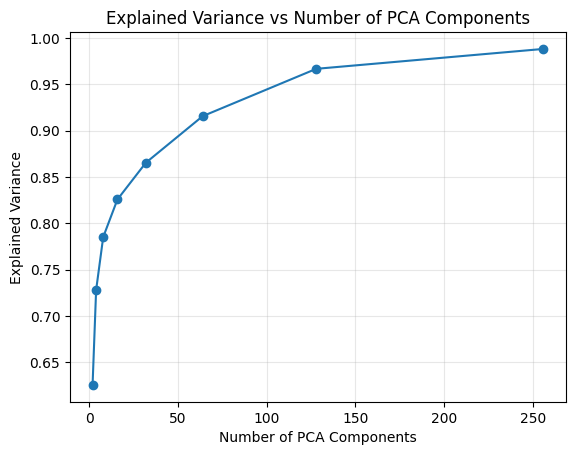

In [18]:
# first define some components and plot the explained variance of the PCA
n_components = [ 2, 4, 8, 16, 32, 64, 128, 256 ]

explained_variance_results = []

# manually perform the power-scaling and standardization
X_pow = power_scale(X)
X_scaled = StandardScaler().fit_transform(X_pow)

for n_component in tqdm( n_components, desc="Evaluating PCA components"):

    # fit pca with X_scaled
    pca = PCA(n_components=n_component)
    pca.fit(X_scaled)

    # get the explained variance as sum of the ratios `pca.explained_variance_ratio_`
    explained_variance = np.sum(pca.explained_variance_ratio_)
    explained_variance_results.append(explained_variance)

# Plot explained variance vs number of components
plt.plot(n_components, explained_variance_results, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs Number of PCA Components')
plt.grid(True, alpha=0.3)
plt.show()



Evaluating classifier: KNeighborsClassifier


PCA sizes for KNeighborsClassifier:   0%|          | 0/8 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
PCA sizes for KNeighborsClassifier:  12%|█▎        | 1/8 [00:06<00:44,  6.32s/it]

{'fit_time': array([1.73952651, 1.58789587, 1.13472295, 1.11128259, 1.00053287,
       1.03824806, 0.97345304, 1.04849744, 0.99705887, 0.94288731]), 'score_time': array([0.06757164, 0.04874349, 0.04332829, 0.04193807, 0.04204679,
       0.04122281, 0.04268861, 0.04450321, 0.04666901, 0.02499676]), 'test_score': array([0.48084677, 0.57056452, 0.42842742, 0.55398587, 0.58526741,
       0.45408678, 0.48839556, 0.6024218 , 0.55196771, 0.51664985])}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
PCA sizes for KNeighborsClassifier:  25%|██▌       | 2/8 [00:12<00:35,  5.95s/it]

{'fit_time': array([1.07736659, 1.08568001, 1.06428838, 1.07351327, 1.02973938,
       1.05344009, 1.04948688, 1.02420354, 1.05109262, 1.04870963]), 'score_time': array([0.04811025, 0.07233453, 0.04508543, 0.04332733, 0.04926753,
       0.04494166, 0.04486108, 0.04790521, 0.04584312, 0.03399086]), 'test_score': array([0.57862903, 0.63407258, 0.57056452, 0.6740666 , 0.74974773,
       0.60343088, 0.62764884, 0.66195762, 0.64177598, 0.69727548])}


...

{'fit_time': array([3.56885862, 3.2838366 , 3.72701621, 3.26986074, 5.164433  ,
       5.22833371, 3.4295969 , 3.21253467, 3.14788342, 3.32081795]), 'score_time': array([0.03682017, 0.03721023, 0.06928086, 0.04592443, 0.03838873,
       0.0413456 , 0.03742194, 0.03718495, 0.03674269, 0.02265644]), 'test_score': array([0.49899194, 0.55040323, 0.53629032, 0.63269425, 0.62663976,
       0.58829465, 0.57719475, 0.60544904, 0.60645812, 0.6074672 ])}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
PCA sizes for DecisionTreeClassifier:  88%|████████▊ | 7/8 [01:36<00:19, 19.93s/it]

{'fit_time': array([8.57390285, 7.37689853, 6.53454232, 5.71589589, 7.11831188,
       7.69007492, 6.56158543, 5.8975656 , 5.49042249, 6.14219928]), 'score_time': array([0.04547501, 0.04377699, 0.04073858, 0.0425024 , 0.07929444,
       0.09799886, 0.04052258, 0.04010582, 0.05310845, 0.03880906]), 'test_score': array([0.53830645, 0.56451613, 0.53931452, 0.62058527, 0.63773966,
       0.58930373, 0.58829465, 0.57114026, 0.57921292, 0.60343088])}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
                                                                                   

{'fit_time': array([14.24388814, 11.96481466, 15.66339517, 12.05294037, 12.83183432,
       13.6073041 , 13.52956319, 13.61867285, 12.69203591, 11.94489956]), 'score_time': array([0.09293747, 0.04891253, 0.04717326, 0.04986334, 0.04997993,
       0.04808283, 0.04807067, 0.047472  , 0.04832268, 0.02906394]), 'test_score': array([0.49697581, 0.55645161, 0.53326613, 0.60847629, 0.62865792,
       0.57719475, 0.56004036, 0.57719475, 0.62159435, 0.59737639])}


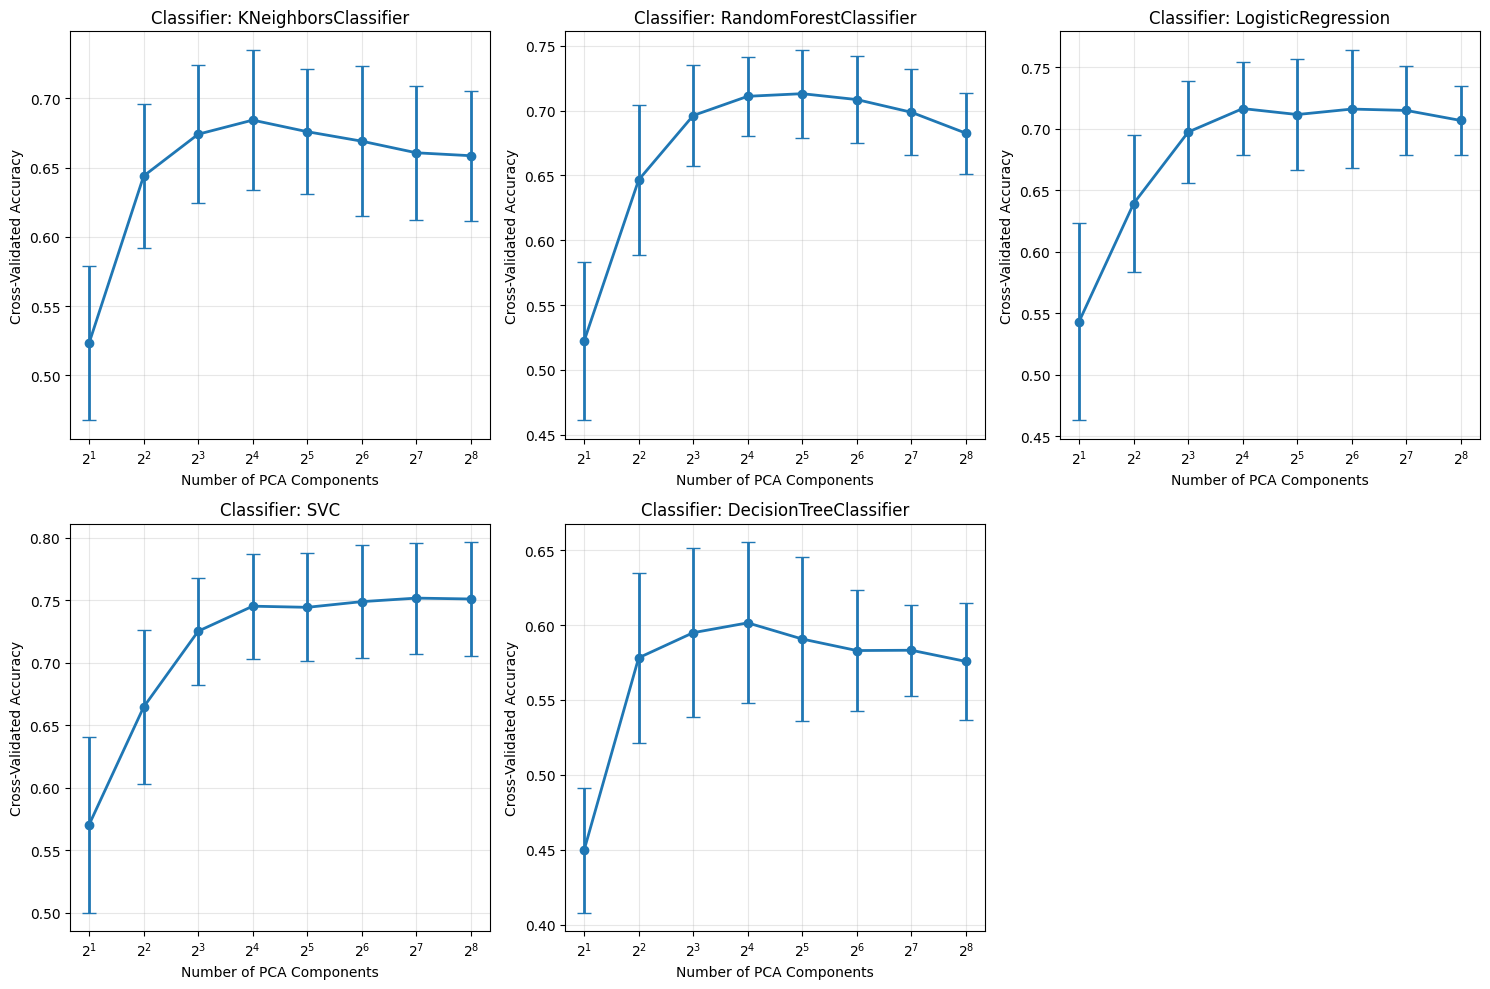


========== BEST PCA SIZE PER CLASSIFIER ==========
KNeighborsClassifier → PCA=16   | Accuracy = 68.43%
RandomForestClassifier → PCA=32   | Accuracy = 71.30%
LogisticRegression   → PCA=16   | Accuracy = 71.65%
SVC                  → PCA=128  | Accuracy = 75.16%
DecisionTreeClassifier → PCA=16   | Accuracy = 60.15%


In [25]:

# Plot accuracy vs number of PCA components with error bars

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

best_models = []

for i, classifier in enumerate(classifiers): # Changed loop to iterate over classifiers
    ax = axes[i] # Assign the correct axis for the current classifier

    print(f"\nEvaluating classifier: {classifier.__class__.__name__}")

    # create the pipelines for each pca components
    # pipelines =

    # perform cross-validation for each classifier pipeline using cross_validate
    cv_results = []

    # ...

    for n_comp in tqdm(n_components, desc=f"PCA sizes for {classifier.__class__.__name__}", leave=False):
        # Build pipeline dynamically
        pipe = make_pipeline(
            FunctionTransformer(power_scale, validate=False),
            StandardScaler(),
            PCA(n_components=n_comp),
            classifier
        )

        # LOSO cross-validation
        cv_out = cross_validate(
            pipe,
            X=X,
            y=y,
            groups=groups,
            cv=len(features),       # LOSO
            scoring="accuracy",
            n_jobs=-1
        )
        print(cv_out)
        mean_acc = cv_out["test_score"].mean()
        std_acc  = cv_out["test_score"].std()

        cv_results.append({
            "n_components": n_comp,
            "mean_accuracy": mean_acc,
            "std_accuracy": std_acc
        })

    # ----------------------------------

    cv_df = pd.DataFrame(cv_results)

    best_idx = cv_df["mean_accuracy"].idxmax()
    best_models.append((
        classifier.__class__.__name__,
        cv_df.loc[best_idx, "n_components"],
        cv_df.loc[best_idx, "mean_accuracy"]
    ))

    ax.errorbar(
        cv_df['n_components'],
        cv_df['mean_accuracy'],
        yerr=cv_df['std_accuracy'],
        marker='o',
        linewidth=2,
        capsize=5,
    )
    ax.set_xlabel('Number of PCA Components')
    ax.set_ylabel('Cross-Validated Accuracy')
    ax.set_title(f'Classifier: {classifier.__class__.__name__}')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log', base=2)

# Hide extra subplot if you have only 5 classifiers
if len(classifiers) < len(axes):
    for j in range(len(classifiers), len(axes)): # Iterate over remaining axes
        axes[j].axis("off") # Turn off additional axes

plt.tight_layout()
plt.show()

# print best classifier
print("\n========== BEST PCA SIZE PER CLASSIFIER ==========")
for name, n_comp, score in best_models:
    print(f"{name:20s} \u2192 PCA={n_comp:<4d} | Accuracy = {score:.2%}")


## Exercise 1.7: Model Deployment - Training, Persistence, and Evaluation on Unseen Data

### From Cross-Validation to Production

Up to this point, we've used cross-validation to **estimate** generalization performance. Now we transition to **deploying** a final model for real-world use.

### The Deployment Pipeline
- Choose the Best Pipeline
- Train on Full Training Set ( eventho we could use LOSO cross validation results to avoid specific subjects )
- Save the model to the disk to restore it in any moment
- Load the saved model and test it to new and unseen data

Notes:
We serialize the trained pipeline to disk using Python's `pickle` module:

```python
with open("best_sklearn_model.pkl", "wb") as f:
    dump(best_pipeline, f)
```

**Benefits of persistence:**
- **Reproducibility**: Same model can be reused without retraining
- **Deployment**: Load model in production environments (web services, embedded systems)
- **Versioning**: Save different model versions for comparison
- **Efficiency**: Avoid expensive retraining for inference


We evaluate on subjects 11-15 (completely unseen during training or CV):

**Metrics:**
1. **Confusion Matrix (normalized)**: Shows per-class accuracy and common misclassifications
   - Diagonal = correct predictions
   - Off-diagonal = confusion patterns (e.g., N1 ↔ N2, Wake ↔ REM)
   
2. **Classification Report**: Provides per-class precision, recall, F1-score
   - **Precision**: Of all predicted N2, how many were actually N2?
   - **Recall**: Of all actual N2, how many did we detect?
   - **F1-score**: Harmonic mean balancing precision and recall

### Interpreting Results

**What to look for in the confusion matrix:**
- **Strong diagonal**: High per-stage accuracy
- **Adjacent confusions**: N1 ↔ N2 confusion is common (transitional stages)
- **Wake vs REM**: May confuse due to similar high-frequency EEG
- **N3 accuracy**: Should be high (distinctive slow-wave activity)

**What to look for in the classification report:**
- **Macro vs weighted averages**:
  - Macro = simple average across classes (treats all stages equally)
  - Weighted = accounts for class imbalance (more realistic for this application)
- **Per-class performance**: Identify which stages are hardest to classify
- **Comparison to CV**: Test accuracy should be similar to CV estimates (validates our methodology)

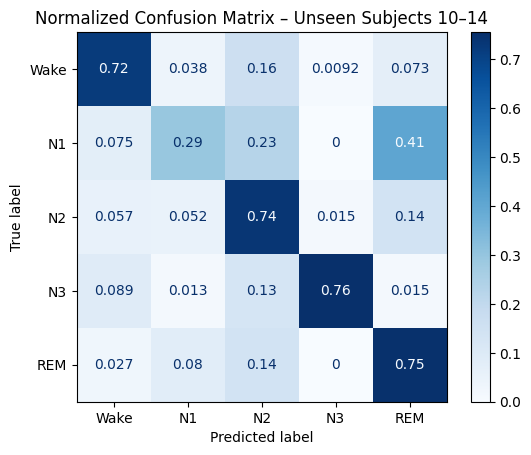

,Wake,N1,N2,N3,REM,accuracy,macro avg,weighted avg
precision,0.823002,0.182353,0.786678,0.886957,0.578593,0.720198,0.651516,0.746948
recall,0.720261,0.292453,0.735514,0.755556,0.751946,0.720198,0.651146,0.720198
f1-score,0.768212,0.224638,0.760236,0.816000,0.653976,0.720198,0.644612,0.729371
support,1530.000000,212.000000,2537.000000,540.000000,1028.000000,0.720198,5847.000000,5847.000000


In [27]:
# now deploy the best model on the whole training set and save it

best_classifier = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)
best_n_components = 128

best_pipeline = make_pipeline(
    FunctionTransformer(power_scale, validate=False),
    StandardScaler(),
    PCA(n_components=best_n_components),
    best_classifier
)

# Fit the best_pipeline on the entire training dataset (subjects 0-9)
best_pipeline.fit(X, y)

# save the model
with open("best_sklearn_model.pkl", "wb") as f:
   dump(best_pipeline, f)

# load the model
with open("best_sklearn_model.pkl", "rb") as f:
   loaded_model = load(f)

# evaluate the loaded model on subjects 11 to 15

X_test_unseen = []
y_test_unseen = []

for subject_id in range(10, 15): # Changed range to 10-14 for unseen subjects
    feats, stages, freqs = read_subject_features(subject_id)
    X_test_unseen.append(feats)
    y_test_unseen.append(stages)

X_test_unseen = np.vstack(X_test_unseen)
y_test_unseen = np.hstack(y_test_unseen)

y_pred_all = loaded_model.predict(X_test_unseen)
y_true_all = y_test_unseen


# plot the confusion matrix with ConfusionMatrixDisplay.from_predictions

ConfusionMatrixDisplay.from_predictions(
    y_test_unseen,
    y_pred_all,
    normalize="true",
    display_labels=STAGES, # Use global STAGES variable
    cmap="Blues",
)
plt.title("Normalized Confusion Matrix – Unseen Subjects 10–14") # Updated title for unseen subjects
plt.show()

# plot the classification report as a dataframe ( output_dict=True in classification_report )
report = classification_report(y_test_unseen, y_pred_all, output_dict=True, target_names=STAGES)
report_df = pd.DataFrame(report)
report_df